
LEVEL 0: 5-NODE GRAPH  (VERY EASY)
Start=A, Goal=E
Algorithms: BFS, DFS

Running BFS...
  Nodes expanded: 5
  Path: A -> C -> E
  Cost: 2

Running DFS...
  Nodes expanded: 4
  Path: A -> B -> D -> E
  Cost: 3

--- Summary ---
Algorithm    Nodes    Path Len Cost     Insight
BFS          5        2        2.0      BFS: A->C->E, 2 hops, 4 nodes.
DFS          4        3        3.0      DFS: A->B->D->E, 3 hops, 4 nodes.


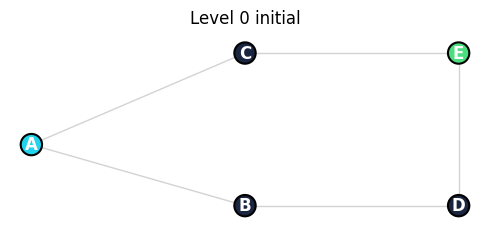

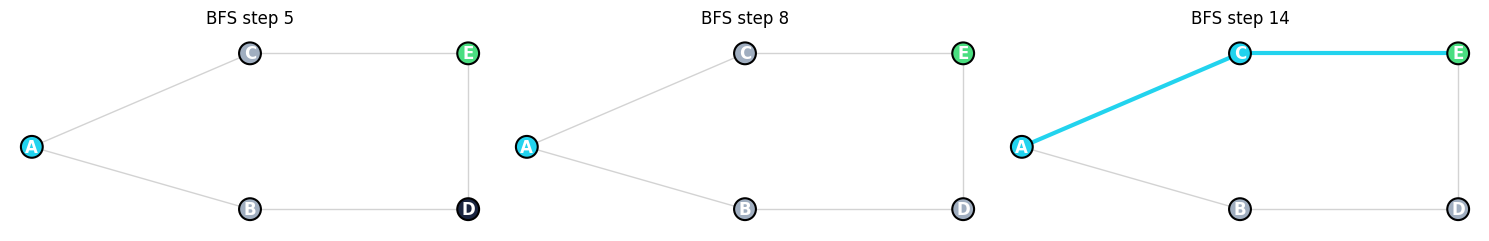

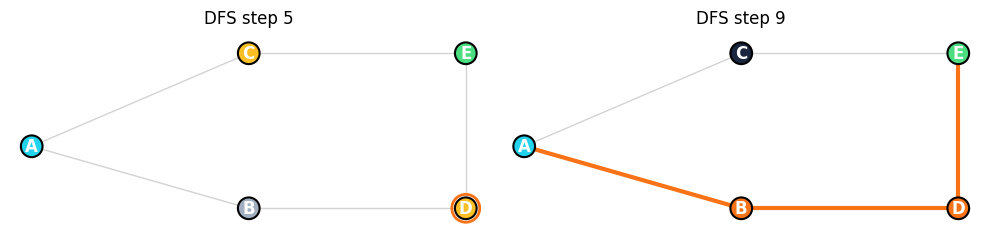

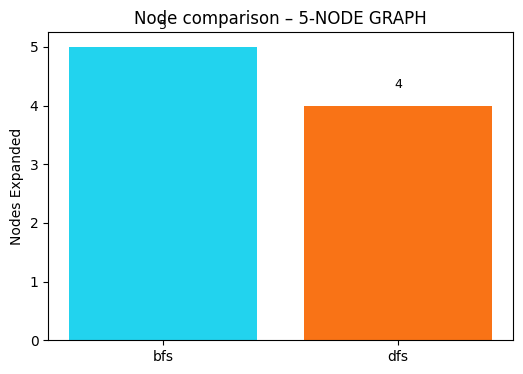


LEVEL 1: 7-NODE GRAPH  (MEDIUM)
Start=A, Goal=G
Algorithms: BFS, DFS, Greedy

Running BFS...
  Nodes expanded: 7
  Path: A -> B -> D -> G
  Cost: 3

Running DFS...
  Nodes expanded: 4
  Path: A -> B -> D -> G
  Cost: 3

Running Greedy...
  Nodes expanded: 4
  Path: A -> B -> D -> G
  Cost: 3

--- Summary ---
Algorithm    Nodes    Path Len Cost     Insight
BFS          7        3        3.0      BFS: A->B->D->G, 3 hops, 6 nodes.
DFS          4        3        3.0      DFS: A->B->D->G, 3 hops, 4 nodes (lucky).
Greedy       4        3        3.0      Greedy: A->B->D->G, 3 hops, 3 nodes.


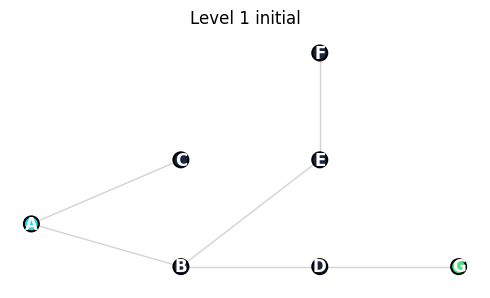

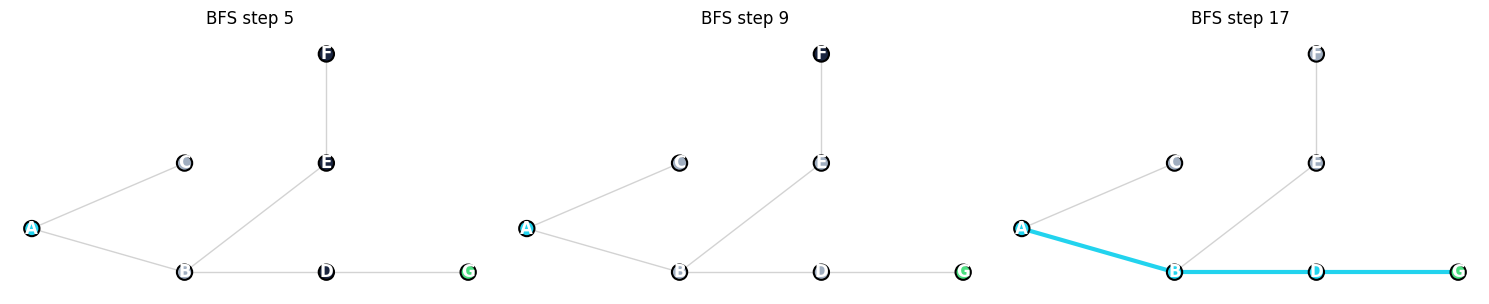

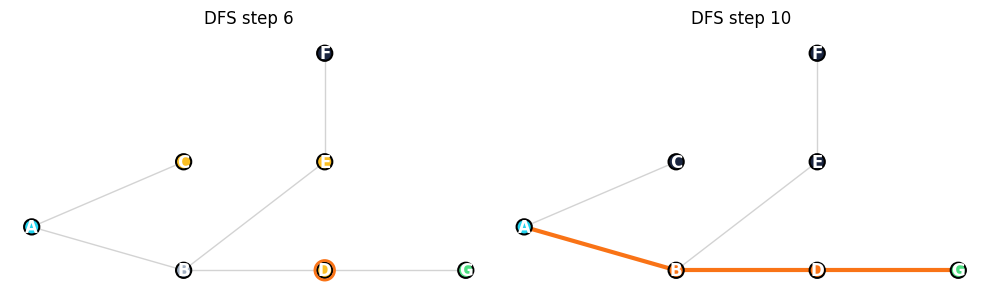

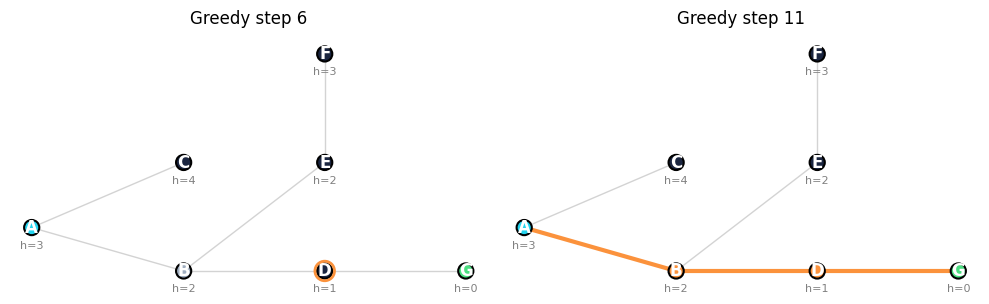

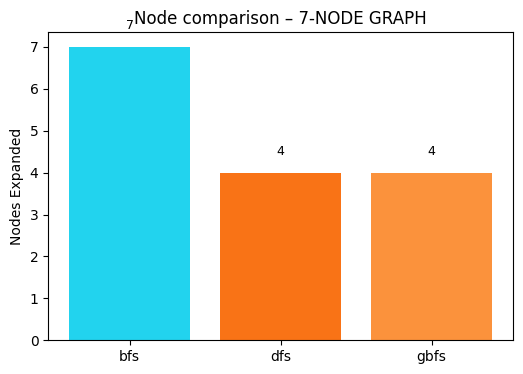


LEVEL 2: 10-NODE GRAPH  (HARD)
Start=A, Goal=H
Algorithms: BFS, DFS, A*

Running BFS...
  Nodes expanded: 9
  Path: A -> B -> C -> H
  Cost: 3

Running DFS...
  Nodes expanded: 4
  Path: A -> B -> C -> H
  Cost: 3

Running A*...
  Nodes expanded: 4
  Path: A -> B -> C -> H
  Cost: 3

--- Summary ---
Algorithm    Nodes    Path Len Cost     Insight
BFS          9        3        3.0      BFS: A->B->C->H, 3 hops, ~8 nodes.
DFS          4        3        3.0      DFS: A->D->...->G then back to A->B->C->H, ~10 nodes.
A*           4        3        3.0      A*: A->B->C->H, 3 hops, 3 nodes.


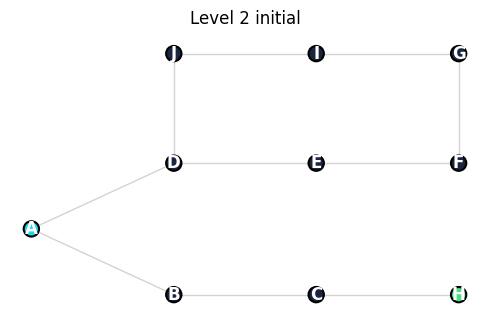

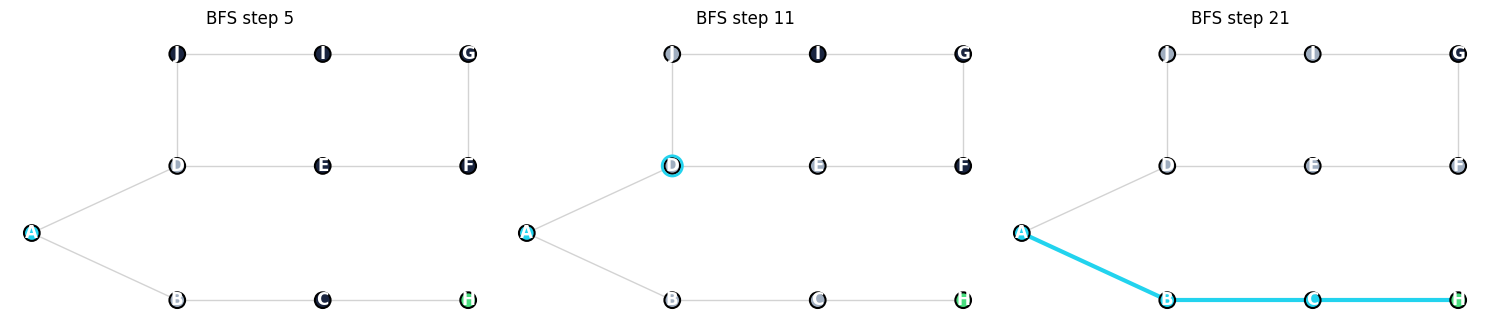

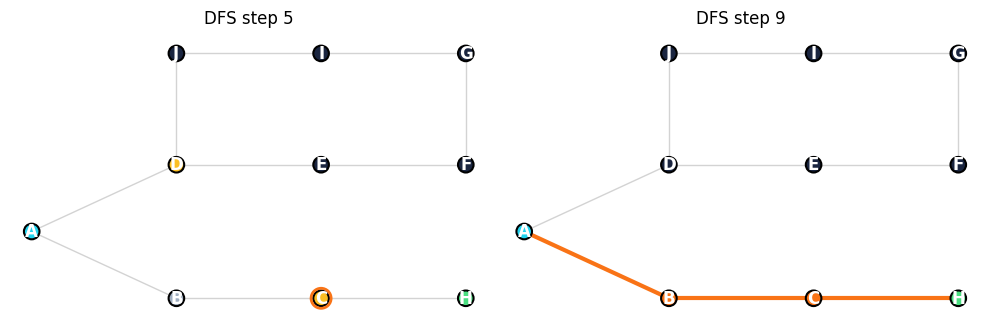

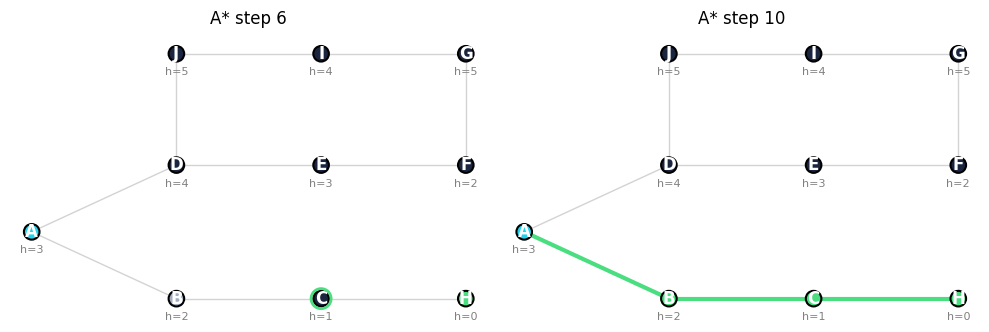

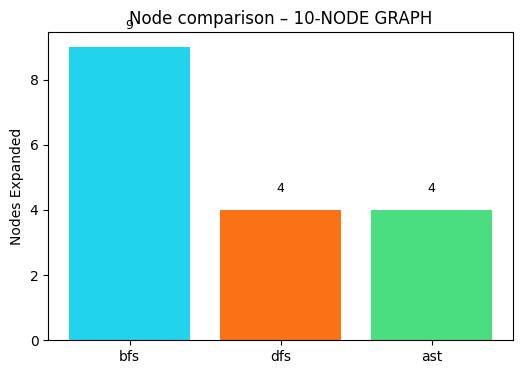


LEVEL 3: 15-NODE WEIGHTED  (VERY HARD)
Start=S, Goal=G
Algorithms: UCS, A*, Greedy

Running UCS...
  Nodes expanded: 9
  Path: S -> C -> D -> E -> G
  Cost: 8

Running A*...
  Nodes expanded: 6
  Path: S -> C -> D -> E -> G
  Cost: 8

Running Greedy...
  Nodes expanded: 5
  Path: S -> K -> L -> F -> G
  Cost: 12

--- Summary ---
Algorithm    Nodes    Path Len Cost     Insight
UCS          9        4        8.0      UCS: S->C->D->E->G cost=8, ~9 nodes.
A*           6        4        8.0      A*: S->C->D->E->G cost=8, 6 nodes.
Greedy       5        4        12.0     Greedy: S->A->B->G cost=12, 4 nodes (suboptimal).


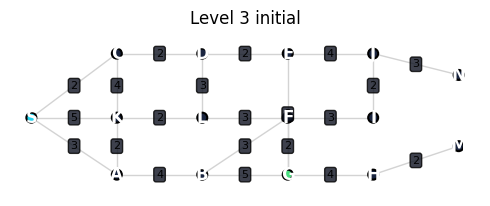

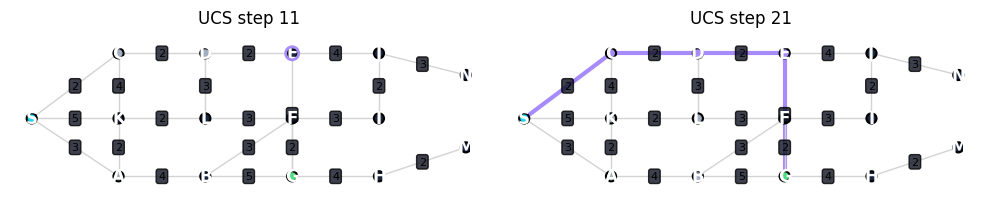

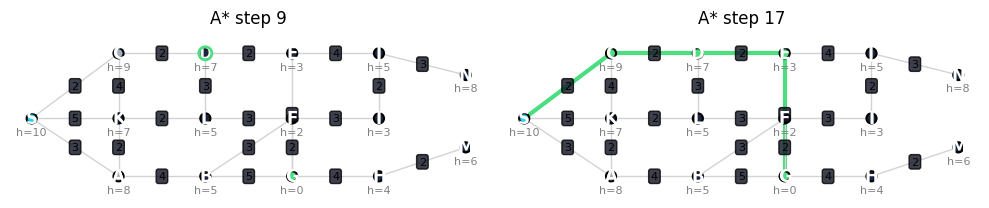

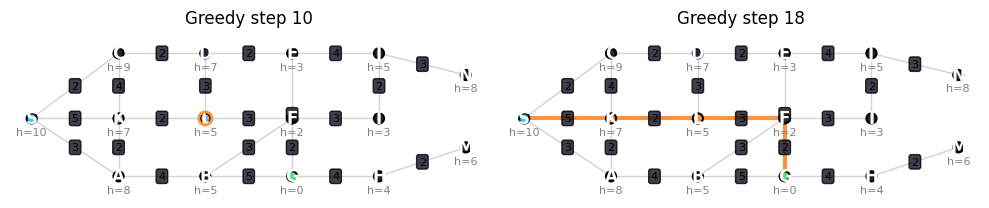

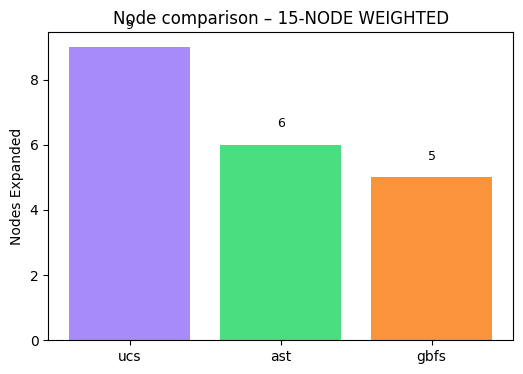


LEVEL 4: 25-NODE MAP  (EXPERT)
Start=S, Goal=Z
Algorithms: BFS, A*, Bidirectional

Running BFS...
  Nodes expanded: 25
  Path: S -> A -> D -> I -> M -> R -> V -> X -> Z
  Cost: 17

Running A*...
  Nodes expanded: 12
  Path: S -> B -> F -> J -> O -> T -> V -> X -> Z
  Cost: 9

Running Bidirectional...
  Nodes expanded: 26
  Path: S -> A -> D -> I -> Z -> X -> V -> R -> M
  Cost: 8

--- Summary ---
Algorithm    Nodes    Path Len Cost     Insight
BFS          25       8        17.0     BFS: ~7 hops, ~22 nodes.
A*           12       8        9.0      A*: optimal path, ~8 nodes.
Bidirectional 26       8        8.0      BiDir: ~10 nodes (5 each side).


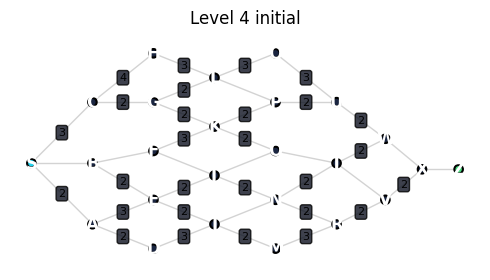

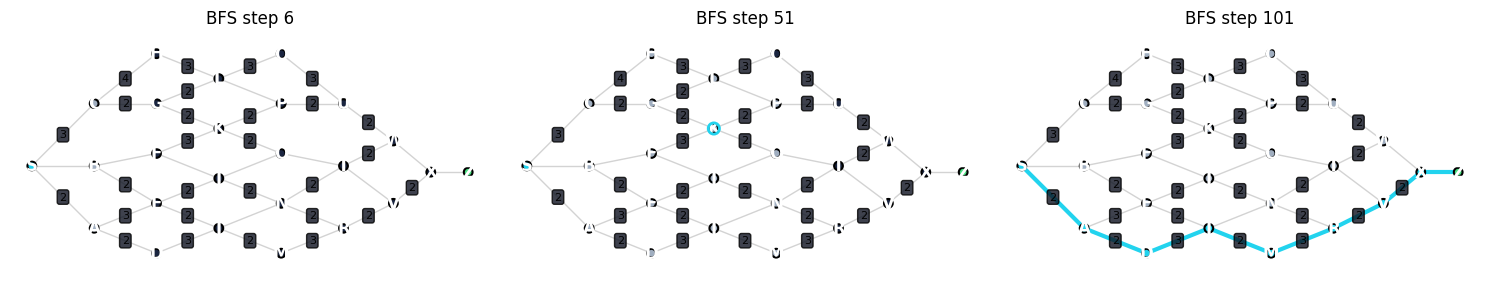

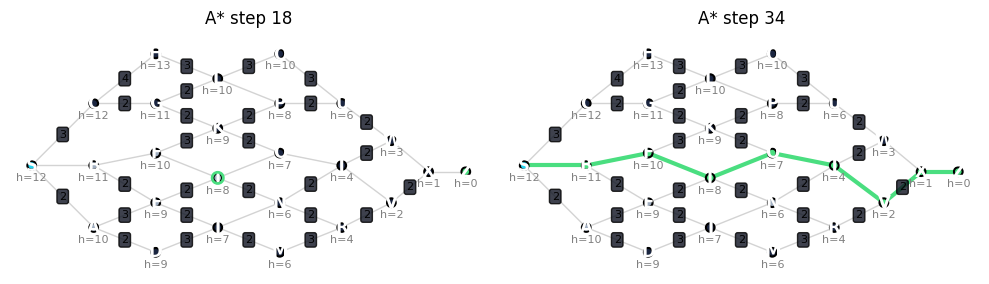

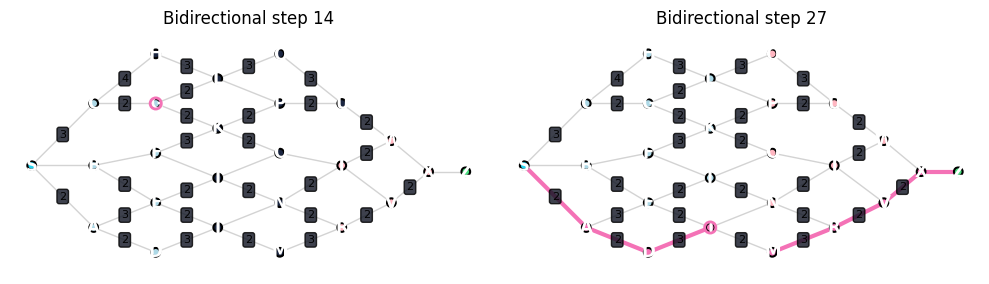

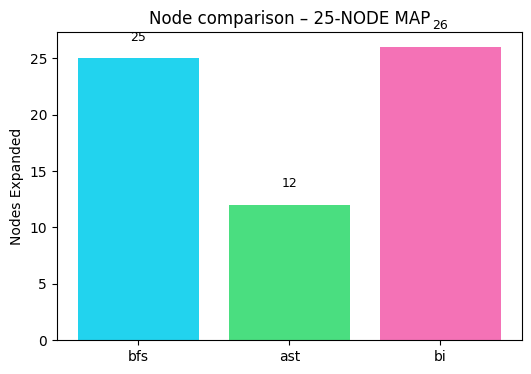


OVERALL COMPARISON

Level 0: 5-NODE GRAPH
Algorithm    Nodes    Path Len Cost    
BFS          5        2        2.0     
DFS          4        3        3.0     

Level 1: 7-NODE GRAPH
Algorithm    Nodes    Path Len Cost    
BFS          7        3        3.0     
DFS          4        3        3.0     
Greedy       4        3        3.0     

Level 2: 10-NODE GRAPH
Algorithm    Nodes    Path Len Cost    
BFS          9        3        3.0     
DFS          4        3        3.0     
A*           4        3        3.0     

Level 3: 15-NODE WEIGHTED
Algorithm    Nodes    Path Len Cost    
UCS          9        4        8.0     
A*           6        4        8.0     
Greedy       5        4        12.0    

Level 4: 25-NODE MAP
Algorithm    Nodes    Path Len Cost    
BFS          25       8        17.0    
A*           12       8        9.0     
Bidirectional 26       8        8.0     


In [2]:
# %% [markdown]
# # Route Finding – Six Graph Search Algorithms Compared
# 
# This notebook implements **BFS, DFS, Uniform Cost Search (UCS), A*, Greedy Best‑First, and Bidirectional BFS** on five different graphs. Each level presents a distinct search challenge (unweighted, weighted, misleading branches, large maps). The algorithms return step‑by‑step logs and we visualise the graph with visited/frontier/path states.

# %% [markdown]
# ## 1. Imports and Helper Data Structures

# %%
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import math
import heapq
from collections import deque

# Priority queue for UCS, A*, Greedy
class PriorityQueue:
    def __init__(self):
        self.heap = []
    def push(self, item, priority):
        heapq.heappush(self.heap, (priority, item))
    def pop(self):
        return heapq.heappop(self.heap)[1]
    def empty(self):
        return len(self.heap) == 0

# MinHeap used in the JavaScript code (we'll use PriorityQueue)
# We'll also keep a simple structure for steps

def reconstruct_path(goal, parent):
    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent.get(cur)
    path.reverse()
    return path

# %% [markdown]
# ## 2. Algorithm Implementations
# Each algorithm returns a dictionary:
# - `steps`: list of step dicts with keys `type`, `node`, `visited`, `frontier`, `path`, `note`, `nodesExplored`, etc.
# - `path`: list of node ids from start to goal
# - `cost`: total path cost
# - `nodesExplored`: number of nodes expanded

# %%
def bfs(nodes, edges, start, goal):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    visited = set()
    parent = {start: None}
    cost_so_far = {start: 0}
    queue = deque([start])
    visited.add(start)
    steps.append({'type': 'visit', 'node': start, 'visited': set(visited),
                  'frontier': set(queue), 'path': [],
                  'note': f'Start at {start}. Add to frontier.', 'nodesExplored': 1})
    count = 1

    while queue:
        cur = queue.popleft()
        if cur == goal:
            path = reconstruct_path(goal, parent)
            steps.append({'type': 'path', 'node': cur, 'visited': set(visited),
                          'frontier': set(), 'path': path,
                          'note': f'GOAL {goal} reached! Path: {"->".join(path)}',
                          'cost': cost_so_far[goal], 'nodesExplored': count})
            return {'steps': steps, 'path': path, 'cost': cost_so_far[goal],
                    'nodesExplored': count}

        for nb, w in adj.get(cur, []):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = cur
                cost_so_far[nb] = cost_so_far[cur] + w
                queue.append(nb)
                count += 1
                steps.append({'type': 'enqueue', 'node': nb, 'from': cur,
                              'visited': set(visited), 'frontier': set(queue),
                              'path': [], 'note': f'Enqueue {nb} from {cur}',
                              'nodesExplored': count})
            else:
                steps.append({'type': 'skip', 'node': nb, 'from': cur,
                              'visited': set(visited), 'frontier': set(queue),
                              'path': [], 'note': f'Skip {nb} (already visited)',
                              'nodesExplored': count})
        steps.append({'type': 'visit', 'node': cur, 'visited': set(visited),
                      'frontier': set(queue), 'path': [],
                      'note': f'Visit {cur}, explore neighbors', 'nodesExplored': count})

    return {'steps': steps, 'path': None, 'cost': float('inf'), 'nodesExplored': count}

def dfs(nodes, edges, start, goal):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    visited = set()
    parent = {start: None}
    cost_so_far = {start: 0}
    stack = [start]
    count = 0

    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        count += 1
        steps.append({'type': 'visit', 'node': cur, 'visited': set(visited),
                      'frontier': set(stack), 'path': [],
                      'note': f'DFS visit {cur}', 'nodesExplored': count})
        if cur == goal:
            path = reconstruct_path(goal, parent)
            steps.append({'type': 'path', 'node': cur, 'visited': set(visited),
                          'frontier': set(), 'path': path,
                          'note': f'GOAL! Path: {"->".join(path)}',
                          'cost': cost_so_far[goal], 'nodesExplored': count})
            return {'steps': steps, 'path': path, 'cost': cost_so_far[goal],
                    'nodesExplored': count}

        # push neighbors in reverse order so that first neighbor in adjacency is popped first (LIFO)
        nbrs = list(adj.get(cur, []))
        nbrs.reverse()
        for nb, w in nbrs:
            if nb not in visited:
                parent[nb] = cur
                cost_so_far[nb] = cost_so_far[cur] + w
                stack.append(nb)
                steps.append({'type': 'enqueue', 'node': nb, 'from': cur,
                              'visited': set(visited), 'frontier': set(stack),
                              'path': [], 'note': f'Push {nb} onto stack',
                              'nodesExplored': count})

    return {'steps': steps, 'path': None, 'cost': float('inf'), 'nodesExplored': count}

def ucs(nodes, edges, start, goal):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    closed = set()
    parent = {start: None}
    g = {start: 0}
    pq = PriorityQueue()
    pq.push(start, 0)
    count = 0

    steps.append({'type': 'visit', 'node': start, 'visited': set(closed),
                  'frontier': set(), 'path': [],
                  'note': f'UCS start at {start}, g=0', 'nodesExplored': count})

    while not pq.empty():
        cur = pq.pop()
        if cur in closed:
            continue
        closed.add(cur)
        count += 1
        steps.append({'type': 'visit', 'node': cur, 'visited': set(closed),
                      'frontier': set(), 'path': [],
                      'note': f'UCS expand {cur} g={g[cur]:.1f}',
                      'nodesExplored': count})
        if cur == goal:
            path = reconstruct_path(goal, parent)
            steps.append({'type': 'path', 'node': cur, 'visited': set(closed),
                          'frontier': set(), 'path': path,
                          'note': f'GOAL! Cost={g[cur]:.1f} Path: {"->".join(path)}',
                          'cost': g[cur], 'nodesExplored': count})
            return {'steps': steps, 'path': path, 'cost': g[cur],
                    'nodesExplored': count}

        for nb, w in adj.get(cur, []):
            new_g = g[cur] + w
            if nb not in g or new_g < g[nb]:
                g[nb] = new_g
                parent[nb] = cur
                pq.push(nb, new_g)
                steps.append({'type': 'relax', 'node': nb, 'from': cur,
                              'visited': set(closed), 'frontier': set(),
                              'path': [], 'note': f'Relax {nb} new g={new_g:.1f}',
                              'nodesExplored': count})

    return {'steps': steps, 'path': None, 'cost': float('inf'), 'nodesExplored': count}

def a_star(nodes, edges, start, goal, heuristic):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    closed = set()
    parent = {start: None}
    g = {start: 0}
    pq = PriorityQueue()
    h0 = heuristic.get(start, 0)
    pq.push(start, h0)
    count = 0

    steps.append({'type': 'visit', 'node': start, 'visited': set(closed),
                  'frontier': set(), 'path': [],
                  'note': f'A* start at {start} h={h0} f={h0}', 'nodesExplored': count})

    while not pq.empty():
        cur = pq.pop()
        if cur in closed:
            continue
        closed.add(cur)
        count += 1
        f = g[cur] + heuristic.get(cur, 0)
        steps.append({'type': 'visit', 'node': cur, 'visited': set(closed),
                      'frontier': set(), 'path': [],
                      'note': f'A* expand {cur} g={g[cur]:.1f} h={heuristic.get(cur,0)} f={f:.1f}',
                      'nodesExplored': count})
        if cur == goal:
            path = reconstruct_path(goal, parent)
            steps.append({'type': 'path', 'node': cur, 'visited': set(closed),
                          'frontier': set(), 'path': path,
                          'note': f'GOAL! Cost={g[cur]:.1f} Path: {"->".join(path)}',
                          'cost': g[cur], 'nodesExplored': count})
            return {'steps': steps, 'path': path, 'cost': g[cur],
                    'nodesExplored': count}

        for nb, w in adj.get(cur, []):
            new_g = g[cur] + w
            if nb not in g or new_g < g[nb]:
                g[nb] = new_g
                parent[nb] = cur
                f_new = new_g + heuristic.get(nb, 0)
                pq.push(nb, f_new)
                steps.append({'type': 'relax', 'node': nb, 'from': cur,
                              'visited': set(closed), 'frontier': set(),
                              'path': [], 'note': f'A* relax {nb} f={f_new:.1f}',
                              'nodesExplored': count})

    return {'steps': steps, 'path': None, 'cost': float('inf'), 'nodesExplored': count}

def greedy_bfs(nodes, edges, start, goal, heuristic):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    closed = set()
    parent = {start: None}
    g = {start: 0}
    pq = PriorityQueue()
    h0 = heuristic.get(start, 0)
    pq.push(start, h0)
    count = 0

    steps.append({'type': 'visit', 'node': start, 'visited': set(closed),
                  'frontier': set(), 'path': [],
                  'note': f'Greedy start at {start} h={h0}', 'nodesExplored': count})

    while not pq.empty():
        cur = pq.pop()
        if cur in closed:
            continue
        closed.add(cur)
        count += 1
        steps.append({'type': 'visit', 'node': cur, 'visited': set(closed),
                      'frontier': set(), 'path': [],
                      'note': f'Greedy expand {cur} h={heuristic.get(cur,0)}',
                      'nodesExplored': count})
        if cur == goal:
            path = reconstruct_path(goal, parent)
            steps.append({'type': 'path', 'node': cur, 'visited': set(closed),
                          'frontier': set(), 'path': path,
                          'note': f'GOAL! Cost={g[cur]:.1f} (may not be optimal) Path: {"->".join(path)}',
                          'cost': g[cur], 'nodesExplored': count})
            return {'steps': steps, 'path': path, 'cost': g[cur],
                    'nodesExplored': count}

        for nb, w in adj.get(cur, []):
            if nb not in closed:
                if nb not in g or (g[cur] + w) < g[nb]:
                    g[nb] = g[cur] + w
                    parent[nb] = cur
                pq.push(nb, heuristic.get(nb, 0))
                steps.append({'type': 'enqueue', 'node': nb, 'from': cur,
                              'visited': set(closed), 'frontier': set(),
                              'path': [], 'note': f'Greedy enqueue {nb} h={heuristic.get(nb,0)}',
                              'nodesExplored': count})

    return {'steps': steps, 'path': None, 'cost': float('inf'), 'nodesExplored': count}

def bidirectional_bfs(nodes, edges, start, goal):
    adj = {n['id']: [] for n in nodes}
    for e in edges:
        adj[e['from']].append((e['to'], e['w']))
        adj[e['to']].append((e['from'], e['w']))

    steps = []
    visited_f = {start}
    visited_b = {goal}
    parent_f = {start: None}
    parent_b = {goal: None}
    queue_f = deque([start])
    queue_b = deque([goal])
    count = 2

    def path_from_meet(node):
        # forward part from start to node
        p_f = []
        cur = node
        while cur is not None:
            p_f.append(cur)
            cur = parent_f.get(cur)
        p_f.reverse()
        # backward part from node to goal (excluding node)
        p_b = []
        cur = parent_b.get(node)
        while cur is not None:
            p_b.append(cur)
            cur = parent_b.get(cur)
        p_b.reverse()
        return p_f + p_b

    steps.append({'type': 'visit', 'node': start, 'visited': set(visited_f),
                  'frontier': set(queue_f), 'path': [], 'bidir': True,
                  'visitedF': set(visited_f), 'visitedB': set(visited_b),
                  'note': f'BiDir: start forward from {start}', 'nodesExplored': count})
    steps.append({'type': 'visit', 'node': goal, 'visited': set(visited_b),
                  'frontier': set(queue_b), 'path': [], 'bidir': True,
                  'visitedF': set(visited_f), 'visitedB': set(visited_b),
                  'note': f'BiDir: start backward from {goal}', 'nodesExplored': count})

    meet_node = None

    while queue_f and queue_b:
        # expand forward
        if queue_f:
            cur_f = queue_f.popleft()
            for nb, w in adj.get(cur_f, []):
                if nb not in visited_f:
                    visited_f.add(nb)
                    parent_f[nb] = cur_f
                    queue_f.append(nb)
                    count += 1
                    steps.append({'type': 'enqueue', 'node': nb, 'from': cur_f,
                                  'visited': set(visited_f), 'frontier': set(queue_f),
                                  'path': [], 'bidir': True,
                                  'visitedF': set(visited_f), 'visitedB': set(visited_b),
                                  'note': f'Forward: enqueue {nb}', 'nodesExplored': count})
                    if nb in visited_b:
                        meet_node = nb
                        queue_f.clear()
                        queue_b.clear()
                        break
        if meet_node:
            break
        # expand backward
        if queue_b:
            cur_b = queue_b.popleft()
            for nb, w in adj.get(cur_b, []):
                if nb not in visited_b:
                    visited_b.add(nb)
                    parent_b[nb] = cur_b
                    queue_b.append(nb)
                    count += 1
                    steps.append({'type': 'enqueue', 'node': nb, 'from': cur_b,
                                  'visited': set(visited_b), 'frontier': set(queue_b),
                                  'path': [], 'bidir': True,
                                  'visitedF': set(visited_f), 'visitedB': set(visited_b),
                                  'note': f'Backward: enqueue {nb}', 'nodesExplored': count})
                    if nb in visited_f:
                        meet_node = nb
                        queue_f.clear()
                        queue_b.clear()
                        break
        if meet_node:
            break

    if meet_node:
        full_path = path_from_meet(meet_node)
        cost = len(full_path) - 1
        steps.append({'type': 'path', 'node': meet_node,
                      'visited': set(visited_f).union(visited_b),
                      'frontier': set(), 'path': full_path, 'bidir': True,
                      'visitedF': set(visited_f), 'visitedB': set(visited_b),
                      'note': f'PATHS MET at {meet_node}! Full: {"->".join(full_path)}',
                      'cost': cost, 'nodesExplored': count})
        return {'steps': steps, 'path': full_path, 'cost': cost,
                'nodesExplored': count}
    else:
        return {'steps': steps, 'path': None, 'cost': float('inf'),
                'nodesExplored': count}

# %% [markdown]
# ## 3. Graph Drawing Function
# Draws the graph with current visited/frontier/path information.

# %%
def draw_graph(ax, level, step_data, accent_color, algo_id):
    nodes = level['nodes']
    edges = level['edges']
    start = level['start']
    goal = level['goal']
    visited = step_data.get('visited', set()) if step_data else set()
    frontier = step_data.get('frontier', set()) if step_data else set()
    path = step_data.get('path', []) if step_data else []
    cur_node = step_data.get('node') if step_data else None
    visitedF = step_data.get('visitedF', set()) if step_data else set()
    visitedB = step_data.get('visitedB', set()) if step_data else set()
    is_solved = step_data and step_data.get('type') == 'path'

    # Extract coordinates
    node_pos = {n['id']: (n['x'], n['y']) for n in nodes}
    xs = [n['x'] for n in nodes]
    ys = [n['y'] for n in nodes]
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)
    pad = 0.05 * max(maxx-minx, maxy-miny)
    ax.set_xlim(minx-pad, maxx+pad)
    ax.set_ylim(miny-pad, maxy+pad)
    ax.set_aspect('equal')
    ax.axis('off')

    # Draw edges
    for e in edges:
        x1, y1 = node_pos[e['from']]
        x2, y2 = node_pos[e['to']]
        in_path = False
        if path:
            for i in range(len(path)-1):
                if (path[i]==e['from'] and path[i+1]==e['to']) or (path[i]==e['to'] and path[i+1]==e['from']):
                    in_path = True
                    break
        if is_solved and in_path:
            ax.plot([x1, x2], [y1, y2], color=accent_color, linewidth=3, zorder=1)
        else:
            ax.plot([x1, x2], [y1, y2], color='lightgray', linewidth=1, zorder=1)
        # Edge weight
        if e['w'] != 1:
            mx, my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx, my, str(e['w']), fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='#0d1220', alpha=0.8, boxstyle='round,pad=0.2'))

    # Draw nodes
    for n in nodes:
        nid = n['id']
        x, y = n['x'], n['y']
        # Determine fill color
        if nid == start:
            facecolor = '#22d3ee'
        elif nid == goal:
            facecolor = '#4ade80'
        elif is_solved and nid in path:
            facecolor = accent_color
        elif algo_id == 'bi' and visitedF and visitedB:
            if nid in visitedF and nid in visitedB:
                facecolor = '#c084fc'
            elif nid in visitedF:
                facecolor = 'lightblue'
            elif nid in visitedB:
                facecolor = 'lightpink'
            else:
                facecolor = '#1a2540'
        elif nid in visited:
            facecolor = '#a0aec0'
        elif nid in frontier:
            facecolor = '#fbbf24'
        else:
            facecolor = '#1a2540'

        # Draw node
        circle = patches.Circle((x, y), radius=7, facecolor=facecolor,
                                edgecolor='black', linewidth=1.5, zorder=2)
        ax.add_patch(circle)

        # Node label
        ax.text(x, y, nid, fontsize=12, fontweight='bold',
                ha='center', va='center', color='white', zorder=3)

        # Heuristic label for A*/Greedy
        if algo_id in ('ast', 'gbfs') and level.get('heuristic'):
            h = level['heuristic'].get(nid, 0)
            ax.text(x, y-12, f'h={h}', fontsize=8, ha='center', va='top',
                    color='gray', zorder=3)

    # Highlight current node
    if cur_node and cur_node not in (start, goal):
        x, y = node_pos[cur_node]
        circle = patches.Circle((x, y), radius=9, facecolor='none',
                                edgecolor=accent_color, linewidth=2, zorder=4)
        ax.add_patch(circle)

    ax.set_title(step_data.get('note', '')[:60], fontsize=9)

# %% [markdown]
# ## 4. Define the Five Graph Levels (from the HTML)

# %%
levels = [
    # Level 0: 5 nodes (unweighted)
    {
        'label': '5-NODE GRAPH', 'diff': 'VERY EASY', 'algos': ['bfs','dfs'],
        'start': 'A', 'goal': 'E',
        'nodes': [
            {'id':'A', 'x':80, 'y':100}, {'id':'B', 'x':220, 'y':60},
            {'id':'C', 'x':220, 'y':160}, {'id':'D', 'x':360, 'y':60},
            {'id':'E', 'x':360, 'y':160}
        ],
        'edges': [
            {'from':'A','to':'B','w':1}, {'from':'A','to':'C','w':1},
            {'from':'B','to':'D','w':1}, {'from':'D','to':'E','w':1},
            {'from':'C','to':'E','w':1}
        ],
        'heuristic': {'A':4,'B':2,'C':1,'D':1,'E':0},
        'insight': {
            'bfs': 'BFS: A->C->E, 2 hops, 4 nodes.',
            'dfs': 'DFS: A->B->D->E, 3 hops, 4 nodes.'
        }
    },
    # Level 1: 7 nodes (unweighted)
    {
        'label': '7-NODE GRAPH', 'diff': 'MEDIUM', 'algos': ['bfs','dfs','gbfs'],
        'start': 'A', 'goal': 'G',
        'nodes': [
            {'id':'A', 'x':60, 'y':100}, {'id':'B', 'x':200, 'y':60},
            {'id':'C', 'x':200, 'y':160}, {'id':'D', 'x':330, 'y':60},
            {'id':'E', 'x':330, 'y':160}, {'id':'F', 'x':330, 'y':260},
            {'id':'G', 'x':460, 'y':60}
        ],
        'edges': [
            {'from':'A','to':'B','w':1}, {'from':'A','to':'C','w':1},
            {'from':'B','to':'D','w':1}, {'from':'B','to':'E','w':1},
            {'from':'E','to':'F','w':1}, {'from':'D','to':'G','w':1}
        ],
        'heuristic': {'A':3,'B':2,'C':4,'D':1,'E':2,'F':3,'G':0},
        'insight': {
            'bfs': 'BFS: A->B->D->G, 3 hops, 6 nodes.',
            'dfs': 'DFS: A->B->D->G, 3 hops, 4 nodes (lucky).',
            'gbfs': 'Greedy: A->B->D->G, 3 hops, 3 nodes.'
        }
    },
    # Level 2: 10 nodes (unweighted, misleading)
    {
        'label': '10-NODE GRAPH', 'diff': 'HARD', 'algos': ['bfs','dfs','ast'],
        'start': 'A', 'goal': 'H',
        'nodes': [
            {'id':'A', 'x':60, 'y':140}, {'id':'B', 'x':190, 'y':80},
            {'id':'C', 'x':320, 'y':80}, {'id':'D', 'x':190, 'y':200},
            {'id':'E', 'x':320, 'y':200}, {'id':'F', 'x':450, 'y':200},
            {'id':'G', 'x':450, 'y':300}, {'id':'H', 'x':450, 'y':80},
            {'id':'I', 'x':320, 'y':300}, {'id':'J', 'x':190, 'y':300}
        ],
        'edges': [
            {'from':'A','to':'B','w':1}, {'from':'A','to':'D','w':1},
            {'from':'B','to':'C','w':1}, {'from':'C','to':'H','w':1},
            {'from':'D','to':'E','w':1}, {'from':'E','to':'F','w':1},
            {'from':'F','to':'G','w':1}, {'from':'D','to':'J','w':1},
            {'from':'J','to':'I','w':1}, {'from':'I','to':'G','w':1}
        ],
        'heuristic': {'A':3,'B':2,'C':1,'D':4,'E':3,'F':2,'G':5,'H':0,'I':4,'J':5},
        'insight': {
            'bfs': 'BFS: A->B->C->H, 3 hops, ~8 nodes.',
            'dfs': 'DFS: A->D->...->G then back to A->B->C->H, ~10 nodes.',
            'ast': 'A*: A->B->C->H, 3 hops, 3 nodes.'
        }
    },
    # Level 3: 15 nodes (weighted)
    {
        'label': '15-NODE WEIGHTED', 'diff': 'VERY HARD', 'algos': ['ucs','ast','gbfs'],
        'start': 'S', 'goal': 'G',
        'nodes': [
            {'id':'S', 'x':70, 'y':170}, {'id':'A', 'x':190, 'y':90},
            {'id':'B', 'x':310, 'y':90}, {'id':'C', 'x':190, 'y':260},
            {'id':'D', 'x':310, 'y':260}, {'id':'E', 'x':430, 'y':260},
            {'id':'G', 'x':430, 'y':90}, {'id':'F', 'x':430, 'y':170},
            {'id':'H', 'x':550, 'y':90}, {'id':'I', 'x':550, 'y':170},
            {'id':'J', 'x':550, 'y':260}, {'id':'K', 'x':190, 'y':170},
            {'id':'L', 'x':310, 'y':170}, {'id':'M', 'x':670, 'y':130},
            {'id':'N', 'x':670, 'y':230}
        ],
        'edges': [
            {'from':'S','to':'A','w':3}, {'from':'S','to':'C','w':2}, {'from':'S','to':'K','w':5},
            {'from':'A','to':'B','w':4}, {'from':'A','to':'K','w':2},
            {'from':'B','to':'G','w':5}, {'from':'B','to':'F','w':3},
            {'from':'C','to':'D','w':2}, {'from':'C','to':'K','w':4},
            {'from':'D','to':'E','w':2}, {'from':'D','to':'L','w':3},
            {'from':'E','to':'G','w':2}, {'from':'E','to':'J','w':4},
            {'from':'K','to':'L','w':2}, {'from':'L','to':'F','w':3},
            {'from':'F','to':'G','w':2}, {'from':'F','to':'I','w':3},
            {'from':'G','to':'H','w':4}, {'from':'H','to':'M','w':2},
            {'from':'I','to':'J','w':2}, {'from':'J','to':'N','w':3}
        ],
        'heuristic': {'S':10,'A':8,'B':5,'C':9,'D':7,'E':3,'G':0,'F':2,'H':4,'I':3,'J':5,'K':7,'L':5,'M':6,'N':8},
        'insight': {
            'ucs': 'UCS: S->C->D->E->G cost=8, ~9 nodes.',
            'ast': 'A*: S->C->D->E->G cost=8, 6 nodes.',
            'gbfs': 'Greedy: S->A->B->G cost=12, 4 nodes (suboptimal).'
        }
    },
    # Level 4: 25 nodes (large map)
    {
        'label': '25-NODE MAP', 'diff': 'EXPERT', 'algos': ['bfs','ast','bi'],
        'start': 'S', 'goal': 'Z',
        'nodes': [
            {'id':'S','x':60,'y':200}, {'id':'A','x':160,'y':100}, {'id':'B','x':160,'y':200},
            {'id':'C','x':160,'y':300}, {'id':'D','x':260,'y':60}, {'id':'E','x':260,'y':140},
            {'id':'F','x':260,'y':220}, {'id':'G','x':260,'y':300}, {'id':'H','x':260,'y':380},
            {'id':'I','x':360,'y':100}, {'id':'J','x':360,'y':180}, {'id':'K','x':360,'y':260},
            {'id':'L','x':360,'y':340}, {'id':'M','x':460,'y':60}, {'id':'N','x':460,'y':140},
            {'id':'O','x':460,'y':220}, {'id':'P','x':460,'y':300}, {'id':'Q','x':460,'y':380},
            {'id':'R','x':560,'y':100}, {'id':'T','x':560,'y':200}, {'id':'U','x':560,'y':300},
            {'id':'V','x':640,'y':140}, {'id':'W','x':640,'y':240}, {'id':'X','x':700,'y':190},
            {'id':'Z','x':760,'y':190}
        ],
        'edges': [
            {'from':'S','to':'A','w':2},{'from':'S','to':'B','w':1},{'from':'S','to':'C','w':3},
            {'from':'A','to':'D','w':2},{'from':'A','to':'E','w':3},{'from':'B','to':'E','w':2},
            {'from':'B','to':'F','w':1},{'from':'C','to':'G','w':2},{'from':'C','to':'H','w':4},
            {'from':'D','to':'I','w':3},{'from':'E','to':'I','w':2},{'from':'E','to':'J','w':2},
            {'from':'F','to':'J','w':1},{'from':'F','to':'K','w':3},{'from':'G','to':'K','w':2},
            {'from':'G','to':'L','w':2},{'from':'H','to':'L','w':3},{'from':'I','to':'M','w':2},
            {'from':'I','to':'N','w':1},{'from':'J','to':'N','w':2},{'from':'J','to':'O','w':1},
            {'from':'K','to':'O','w':2},{'from':'K','to':'P','w':2},{'from':'L','to':'P','w':1},
            {'from':'L','to':'Q','w':3},{'from':'M','to':'R','w':3},{'from':'N','to':'R','w':2},
            {'from':'N','to':'T','w':2},{'from':'O','to':'T','w':1},{'from':'P','to':'U','w':2},
            {'from':'Q','to':'U','w':3},{'from':'R','to':'V','w':2},{'from':'T','to':'V','w':1},
            {'from':'T','to':'W','w':2},{'from':'U','to':'W','w':2},{'from':'V','to':'X','w':2},
            {'from':'W','to':'X','w':1},{'from':'X','to':'Z','w':1}
        ],
        'heuristic': {
            'S':12,'A':10,'B':11,'C':12,'D':9,'E':9,'F':10,'G':11,'H':13,
            'I':7,'J':8,'K':9,'L':10,'M':6,'N':6,'O':7,'P':8,'Q':10,
            'R':4,'T':4,'U':6,'V':2,'W':3,'X':1,'Z':0
        },
        'insight': {
            'bfs': 'BFS: ~7 hops, ~22 nodes.',
            'ast': 'A*: optimal path, ~8 nodes.',
            'bi': 'BiDir: ~10 nodes (5 each side).'
        }
    }
]

# Map algorithm IDs to run functions
algo_funcs = {
    'bfs': bfs, 'dfs': dfs, 'ucs': ucs,
    'ast': a_star, 'gbfs': greedy_bfs, 'bi': bidirectional_bfs
}
algo_names = {
    'bfs': 'BFS', 'dfs': 'DFS', 'ucs': 'UCS',
    'ast': 'A*', 'gbfs': 'Greedy', 'bi': 'Bidirectional'
}
algo_colors = {
    'bfs': '#22d3ee', 'dfs': '#f97316', 'ucs': '#a78bfa',
    'ast': '#4ade80', 'gbfs': '#fb923c', 'bi': '#f472b6'
}

# %% [markdown]
# ## 5. Run All Levels and Display Results

# %%
all_results = []

for level_idx, level in enumerate(levels):
    print(f"\n{'='*60}")
    print(f"LEVEL {level_idx}: {level['label']}  ({level['diff']})")
    print(f"Start={level['start']}, Goal={level['goal']}")
    print(f"Algorithms: {', '.join(algo_names[a] for a in level['algos'])}")
    print('='*60)

    level_results = {}
    for alg_id in level['algos']:
        print(f"\nRunning {algo_names[alg_id]}...")
        if alg_id in ('ast', 'gbfs'):
            res = algo_funcs[alg_id](level['nodes'], level['edges'],
                                      level['start'], level['goal'],
                                      level['heuristic'])
        else:
            res = algo_funcs[alg_id](level['nodes'], level['edges'],
                                      level['start'], level['goal'])
        level_results[alg_id] = res
        print(f"  Nodes expanded: {res['nodesExplored']}")
        if res['path']:
            print(f"  Path: {' -> '.join(res['path'])}")
            print(f"  Cost: {res['cost']}")
        else:
            print("  No path found")

    # Summary table
    print("\n--- Summary ---")
    print(f"{'Algorithm':<12} {'Nodes':<8} {'Path Len':<8} {'Cost':<8} {'Insight'}")
    for alg_id in level['algos']:
        res = level_results[alg_id]
        path_len = len(res['path'])-1 if res['path'] else '-'
        cost = f"{res['cost']:.1f}" if res['cost'] != float('inf') else '-'
        insight = level['insight'].get(alg_id, '')
        print(f"{algo_names[alg_id]:<12} {res['nodesExplored']:<8} {path_len:<8} {cost:<8} {insight}")

    # Draw initial state
    fig, ax = plt.subplots(1, 1, figsize=(5,4))
    dummy_step = {'type': 'start', 'visited': set(), 'frontier': set(),
                  'path': [], 'node': None}
    draw_graph(ax, level, dummy_step, '#888', '')
    ax.set_title(f"Level {level_idx} initial")
    plt.tight_layout()
    plt.show()

    # Show a few key steps for each algorithm
    for alg_id in level['algos']:
        steps = level_results[alg_id]['steps']
        if not steps:
            continue
        # pick steps: first real action, middle, last
        step_indices = []
        for i, s in enumerate(steps):
            if s['type'] not in ('visit','enqueue','relax','path') and i>0:
                step_indices.append(i)
                break
        if len(steps) > 2:
            step_indices.append(len(steps)//2)
        if len(steps)-1 not in step_indices:
            step_indices.append(len(steps)-1)
        step_indices = sorted(set(step_indices))

        fig, axes = plt.subplots(1, len(step_indices), figsize=(5*len(step_indices), 4))
        if len(step_indices) == 1:
            axes = [axes]
        for ax, idx in zip(axes, step_indices):
            s = steps[idx]
            draw_graph(ax, level, s, algo_colors[alg_id], alg_id)
            ax.set_title(f"{algo_names[alg_id]} step {idx+1}")
        plt.tight_layout()
        plt.show()

    # Node comparison bar chart
    plt.figure(figsize=(6,4))
    algs = level['algos']
    nodes = [level_results[a]['nodesExplored'] for a in algs]
    colors = [algo_colors[a] for a in algs]
    bars = plt.bar(algs, nodes, color=colors)
    plt.ylabel('Nodes Expanded')
    plt.title(f'Node comparison – {level["label"]}')
    for bar, val in zip(bars, nodes):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05*max(nodes),
                 str(val), ha='center', va='bottom', fontsize=9)
    plt.show()

    all_results.append((level_idx, level_results))

# %% [markdown]
# ## 6. Overall Comparison Table

# %%
print("\n" + "="*60)
print("OVERALL COMPARISON")
print("="*60)

for level_idx, level_results in all_results:
    level = levels[level_idx]
    print(f"\nLevel {level_idx}: {level['label']}")
    print(f"{'Algorithm':<12} {'Nodes':<8} {'Path Len':<8} {'Cost':<8}")
    for alg_id in level['algos']:
        res = level_results[alg_id]
        path_len = len(res['path'])-1 if res['path'] else '-'
        cost = f"{res['cost']:.1f}" if res['cost'] != float('inf') else '-'
        print(f"{algo_names[alg_id]:<12} {res['nodesExplored']:<8} {path_len:<8} {cost:<8}")